Total files available for analysis: 19981

               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)
  landmarks                   : Shape (450, 468, 2)        | Dtype float32
  meta_camera_type            : Shape ()                   | Dtype <U12
  meta_chunk_index            : Shape ()                   | Dtype int64
  meta_condition              : Shape ()                   | Dtype <U5
  meta_end_frame              : Shape ()                   | Dtype int64
  meta_num_frames             : Shape ()                   | Dtype int64
  meta_start_frame            : Shape ()                   | Dtype int64
  meta_subject_id             : Shape ()                   | Dtype int64
  meta_view_type              : Shape ()                   | Dtype <U5
  ppg_values                  : Shape (450,)               | Dtype float64
  roi_chin                    : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_chin_199                : Shape (450, 24, 24, 3)     | Dtype uint8
  roi_fore

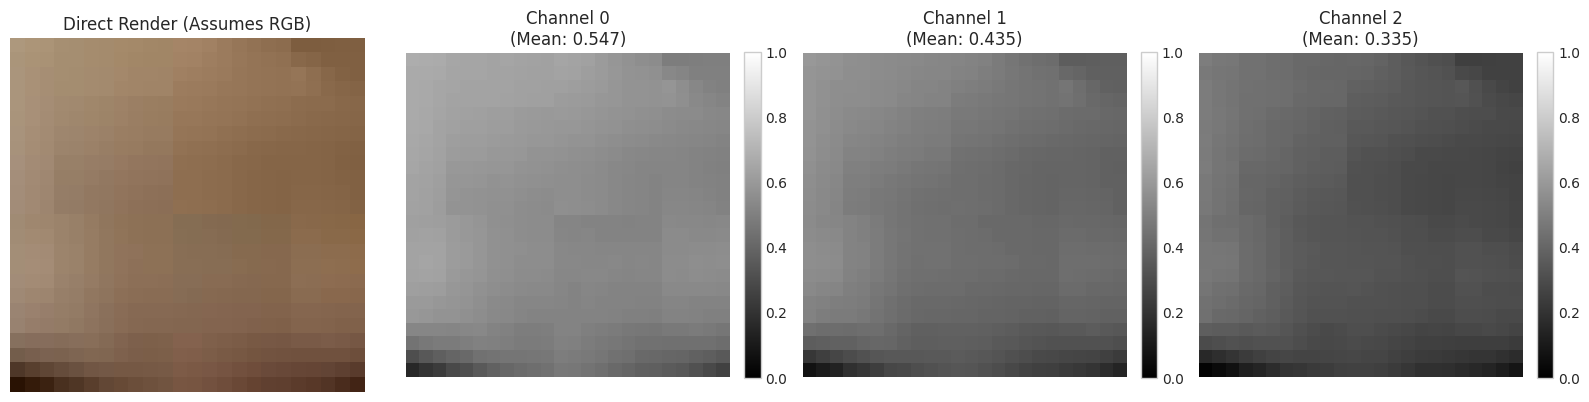

Starting optimization loop...


In [ ]:
import os
import json
import math
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt, welch
import random

# Configure high-quality visualization styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")

# Setup default configurations
PREPROCESSED_DATA_PATH = Path('/home/cristic/preprocessed_data/')
CACHE_FILES = ["valid_files.txt", "train_files_cache.txt", "val_files_cache.txt"]
# Force usage of the second GPU (index 1)
gpu_id = 1 
DEVICE = torch.device(f'cuda:{gpu_id}' if torch.cuda.is_available() else 'cpu')
MODEL_SAVE_PATH = Path("spatiotemporal_physnet_best_shuffle.pth")

# Clean existing cache files before starting run
for cache in CACHE_FILES:
    if os.path.exists(cache):
        try:
            os.remove(cache)
            print(f"Removed old cache: {cache}")
        except Exception as e:
            print(f"Error removing cache {cache}: {e}")

# Strict order representing the 9 sub-ROIs + full face boundary configurations
ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'
]

def inspect_npz_color_space(npz_path, roi_key='roi_forehead'):
    """
    Diagnose NPZ color-space representations and plot channel intensities.
    Ensures RGB channels align with spatial tracking configurations.
    """
    print(f"\nEvaluating color space for path: {npz_path}")
    if not os.path.exists(npz_path):
        print(f"Color Space Inspector Notice: Sample {npz_path} does not exist yet.")
        return

    with np.load(npz_path) as data:
        if roi_key not in data:
            available = [k for k in data.keys() if k.startswith('roi_')]
            if not available:
                print("No ROIs found in file keys.")
                return
            print(f"Key '{roi_key}' not found. Available ROIs: {available}")
            roi_key = available[0]
            
        roi_data = data[roi_key]
        
    print(f"Loaded '{roi_key}' with shape: {roi_data.shape} and dtype: {roi_data.dtype}")
    
    first_frame = roi_data[0].copy()
    
    if first_frame.max() > 1.0:
        first_frame_norm = first_frame.astype(np.float32) / 255.0
    else:
        first_frame_norm = first_frame.astype(np.float32)
        
    c0 = first_frame_norm[:, :, 0]
    c1 = first_frame_norm[:, :, 1]
    c2 = first_frame_norm[:, :, 2]
    
    mean_c0, mean_c1, mean_c2 = c0.mean(), c1.mean(), c2.mean()
    
    print("\n--- Channel Intensity Statistics ---")
    print(f"Channel 0 Mean: {mean_c0:.4f}")
    print(f"Channel 1 Mean: {mean_c1:.4f}")
    print(f"Channel 2 Mean: {mean_c2:.4f}")
    print("------------------------------------\n")
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(first_frame_norm)
    axes[0].set_title("Direct Render (Assumes RGB)")
    axes[0].axis('off')
    
    im0 = axes[1].imshow(c0, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f"Channel 0\n(Mean: {mean_c0:.3f})")
    axes[1].axis('off')
    plt.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04)
    
    im1 = axes[2].imshow(c1, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f"Channel 1\n(Mean: {mean_c1:.3f})")
    axes[2].axis('off')
    plt.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04)
    
    im2 = axes[3].imshow(c2, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f"Channel 2\n(Mean: {mean_c2:.3f})")
    axes[3].axis('off')
    plt.colorbar(im2, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    """Apply zero-phase Butterworth bandpass filter to capture human heart rate (45-150 BPM)."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    """Extract heart rate (BPM) from the dominant peak of the Power Spectral Density."""
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0
    
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

def load_npz_file(file_path):
    """Securely load and parse an NPZ file."""
    try:
        data = np.load(file_path, allow_pickle=True)
        return data
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def analyze_npz_structure(data):
    """Analyze and print the metadata keys and array dimensions of loaded files."""
    if data is None:
        print("NPZ Analysis Error: Provided data object is None.")
        return
    print("\n" + "=" * 75)
    print("               NPZ FILE STRUCTURE SHOWCASE (9-ROI + Face Configuration)")
    print("=" * 75)
    for key in sorted(data.files):
        item = data[key]
        if hasattr(item, 'shape'):
            print(f"  {key:<27} : Shape {str(item.shape):<20} | Dtype {item.dtype}")
        else:
            print(f"  {key:<27} : Metadata / Scalar Object")
    print("=" * 75 + "\n")

def create_synthetic_dataset(target_dir, num_files=6, num_frames=450):
    """Generate mock datasets matching strict multi-ROI formatting standards."""
    target_dir.mkdir(parents=True, exist_ok=True)
    print(f"\nTarget dataset directory '{target_dir}' is empty or missing.")
    print("Generating synthetic 9-ROI + face NPZ dataset mimicking real schemas...")
    
    fs = 30.0
    t = np.arange(num_frames) / fs
    
    for i in range(num_files):
        hr_hz = np.random.uniform(1.0, 1.5)
        bvp = np.sin(2 * np.pi * hr_hz * t) + 0.35 * np.sin(2 * np.pi * (hr_hz * 2) * t)
        bvp += 0.2 * np.sin(2 * np.pi * 0.2 * t)
        bvp = (bvp - np.mean(bvp)) / (np.std(bvp) + 1e-8)
        
        data_dict = {
            'time_deltas': (t * 1000.0).astype(np.float64),
            'ppg_values': bvp.astype(np.float64)
        }
        
        for roi in ROI_ORDER:
            base_skin = np.array([185.0, 125.0, 105.0]) if "eye" not in roi else np.array([210.0, 190.0, 180.0])
            pixel_noise = np.random.normal(0, 1.2, size=(num_frames, 24, 24, 3))
            
            pulse_modulator = np.zeros((num_frames, 24, 24, 3))
            pulse_modulator[..., 0] = bvp[:, None, None] * 0.15
            pulse_modulator[..., 1] = bvp[:, None, None] * 0.55
            pulse_modulator[..., 2] = bvp[:, None, None] * 0.05
            
            roi_frames = (base_skin + pulse_modulator + pixel_noise).clip(0, 255).astype(np.uint8)
            data_dict[roi] = roi_frames
            
        np.savez(target_dir / f"subject_{i+1:02d}_session_01.npz", **data_dict)
    print("Synthetic dataset successfully created!\n")

class PPGMultiROIDataset(Dataset):
    """Optimized Dataset class with inline spatial and temporal sequence augmentations."""
    def __init__(self, file_paths, sequence_length=450, fs=30.0, augment=False):
        self.file_paths = file_paths
        self.sequence_length = sequence_length
        self.fs = fs
        self.augment = augment
        self.samples = []
        
        self._prepare_samples()

    def _prepare_samples(self):
        """Pre-segment matching timelines into sequence lengths."""
        for path in self.file_paths:
            data = load_npz_file(path)
            if data is None:
                continue
            
            ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
            length = len(data[ppg_key])
            num_windows = length // self.sequence_length
            
            for w in range(num_windows):
                start_idx = w * self.sequence_length
                end_idx = start_idx + self.sequence_length
                self.samples.append((path, start_idx, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, start, end = self.samples[idx]
        data = load_npz_file(file_path)
        
        ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
        ppg_segment = data[ppg_key][start:end]
        ppg_segment = butter_bandpass_filter(ppg_segment, fs=self.fs)
        ppg_normalized = (ppg_segment - np.mean(ppg_segment)) / (np.std(ppg_segment) + 1e-8)
        
        roi_inputs = []
        for roi_name in ROI_ORDER:
            actual_key = next((k for k in data.files if roi_name == k), None)
            
            if actual_key is not None:
                roi_data = data[actual_key][start:end]
            else:
                roi_data = np.zeros((self.sequence_length, 24, 24, 3), dtype=np.uint8)
                
            roi_data = roi_data.astype(np.float32) / 255.0
            roi_inputs.append(roi_data)
            
        # Perform coordinated sequence augmentations across all 10 regions
        if self.augment:
            # 50% chance of random horizontal flip
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=2) for roi in roi_inputs]
                
            # 50% chance of random vertical flip
            if np.random.rand() > 0.5:
                roi_inputs = [np.flip(roi, axis=1) for roi in roi_inputs]
                
            # 50% chance of brightness jittering
            if np.random.rand() > 0.5:
                brightness_factor = np.random.uniform(0.9, 1.1)
                roi_inputs = [np.clip(roi * brightness_factor, 0.0, 1.0) for roi in roi_inputs]
                
        # Structure dimension mapping: (10, T, H, W, C) -> (10, C, T, H, W) -> (10 * C, T, H, W)
        stacked_rois = np.stack(roi_inputs, axis=0)
        stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
        stacked_rois = np.reshape(stacked_rois, (10 * 3, self.sequence_length, 24, 24))
        
        return torch.tensor(stacked_rois, dtype=torch.float32), torch.tensor(ppg_normalized, dtype=torch.float32)

class SpatioTemporalPhysNet(nn.Module):
    """
    Spatio-Temporal convolutional network engineered to extract micro-color variations
    harmoniously across 10 face zones (30 raw input channels).
    """
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels
        
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))
        )
        
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        x_spatial = self.spatial_conv(x)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        
        ppg_pred = self.temporal_encoder(x_spatial)
        return torch.squeeze(ppg_pred, dim=1)

class NegativePearsonCorrelationLoss(nn.Module):
    """Loss module measuring BVP signal phase synchronization."""
    def __init__(self):
        super(NegativePearsonCorrelationLoss, self).__init__()

    def forward(self, pred, target):
        pred_mean = torch.mean(pred, dim=-1, keepdim=True)
        target_mean = torch.mean(target, dim=-1, keepdim=True)
        
        pred_centered = pred - pred_mean
        target_centered = target - target_mean
        
        r_num = torch.sum(pred_centered * target_centered, dim=-1)
        r_den = torch.sqrt(torch.sum(pred_centered ** 2, dim=-1) * torch.sum(target_centered ** 2, dim=-1) + 1e-8)
        
        pearson_coeff = r_num / r_den
        return 1.0 - torch.mean(pearson_coeff)

def calculate_metrics(y_pred, y_true, fs=30.0):
    """Extract performance evaluation metrics (PCC, MAE, RMSE, and SNR)."""
    pcc_list, mae_list, rmse_list, snr_list = [], [], [], []
    
    for i in range(len(y_pred)):
        pred, true = y_pred[i], y_true[i]
        
        pcc = np.corrcoef(pred, true)[0, 1]
        pcc_list.append(0.0 if np.isnan(pcc) else pcc)
        
        bpm_pred = calculate_bpm_from_fft(pred, fs=fs)
        bpm_true = calculate_bpm_from_fft(true, fs=fs)
        
        mae_list.append(abs(bpm_pred - bpm_true))
        rmse_list.append((bpm_pred - bpm_true) ** 2)
        
        pred_detrended = pred - np.mean(pred)
        freqs, psd = welch(pred_detrended, fs=fs, nperseg=len(pred_detrended))
        
        gt_freq = bpm_true / 60.0
        signal_mask = (freqs >= (gt_freq - 0.15)) & (freqs <= (gt_freq + 0.15))
        noise_mask = ~signal_mask & (freqs >= 0.75) & (freqs <= 2.5)
        
        signal_power = np.sum(psd[signal_mask])
        noise_power = np.sum(psd[noise_mask]) + 1e-8
        snr_list.append(10 * np.log10(signal_power / noise_power))
        
    return {
        'PCC': np.mean(pcc_list),
        'MAE': np.mean(mae_list),
        'RMSE': math.sqrt(np.mean(rmse_list)),
        'SNR': np.mean(snr_list)
    }

def save_model_checkpoint(model, optimizer, epoch, metrics, save_path=MODEL_SAVE_PATH):
    """Save model checkpoint along with optimizer state and validation metrics."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'metrics': metrics
    }
    torch.save(checkpoint, save_path)
    print(f"Model checkpoint successfully saved to: {save_path}")

# def load_model_checkpoint(save_path, model, optimizer=None):
#     """Load model weights and optional optimizer states from a checkpoint."""
#     if not os.path.exists(save_path):
#         print(f"Checkpoint path {save_path} does not exist.")
#         return None
#     checkpoint = torch.load(save_path, map_location=DEVICE)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     if optimizer is not None and 'optimizer_state_dict' in checkpoint:
#         optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#     print(f"Loaded model checkpoint from: {save_path} (Epoch {checkpoint.get('epoch', 'N/A')})")
#     return checkpoint

if not any(PREPROCESSED_DATA_PATH.glob('*.npz')):
    create_synthetic_dataset(PREPROCESSED_DATA_PATH, num_files=6)

npz_files = sorted(list(PREPROCESSED_DATA_PATH.glob('*.npz')))
print(f"Total files available for analysis: {len(npz_files)}")

first_file_data = load_npz_file(npz_files[0])
analyze_npz_structure(first_file_data)
inspect_npz_color_space(npz_files[0])
###shuffle files
random.seed(42)
shuffled_files = npz_files.copy()
random.shuffle(shuffled_files)

# Perform split on the shuffled list
split_idx = int(len(shuffled_files) * 0.75)
train_split = shuffled_files[:split_idx]
val_split = shuffled_files[split_idx:]

# train_split = npz_files[:int(len(npz_files) * 0.75)]
# val_split = npz_files[int(len(npz_files) * 0.75):]

train_dataset = PPGMultiROIDataset(train_split, augment=True)
val_dataset = PPGMultiROIDataset(val_split, augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,prefetch_factor=4,num_workers=8, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,prefetch_factor=4,num_workers=8, pin_memory=True, persistent_workers=True)

model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
criterion_pearson = NegativePearsonCorrelationLoss()
criterion_mse = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 25
train_losses, val_losses = [], []

print("Starting optimization loop...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion_pearson(outputs, targets) + 0.3 * criterion_mse(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)
    
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs, val_targets = val_inputs.to(DEVICE), val_targets.to(DEVICE)
            val_outputs = model(val_inputs)
            val_loss = criterion_pearson(val_outputs, val_targets) + 0.3 * criterion_mse(val_outputs, val_targets)
            running_val_loss += val_loss.item() * val_inputs.size(0)
            
    val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for val_inputs, val_targets in val_loader:
        val_inputs = val_inputs.to(DEVICE)
        preds = model(val_inputs).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(val_targets.numpy())

all_preds, all_trues = np.array(all_preds), np.array(all_trues)
metrics = calculate_metrics(all_preds, all_trues)

print("\n" + "=" * 50)
print("              VAL METRICS EVALUATION")
print("=" * 50)
print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
print("=" * 50 + "\n")

# Save model and demonstrate loading functionality


In [3]:
def calculate_metrics(y_pred, y_true, fs=30.0):
    """Extract performance evaluation metrics (PCC, MAE, RMSE, and SNR)."""
    pcc_list, mae_list, rmse_list, snr_list = [], [], [], []
    
    for i in range(len(y_pred)):
        pred, true = y_pred[i], y_true[i]
        
        pcc = np.corrcoef(pred, true)[0, 1]
        pcc_list.append(0.0 if np.isnan(pcc) else pcc)
        
        bpm_pred = calculate_bpm_from_fft(pred, fs=fs)
        bpm_true = calculate_bpm_from_fft(true, fs=fs)
        
        mae_list.append(abs(bpm_pred - bpm_true))
        rmse_list.append((bpm_pred - bpm_true) ** 2)
        
        pred_detrended = pred - np.mean(pred)
        freqs, psd = welch(pred_detrended, fs=fs, nperseg=len(pred_detrended))
        
        gt_freq = bpm_true / 60.0
        signal_mask = (freqs >= (gt_freq - 0.15)) & (freqs <= (gt_freq + 0.15))
        noise_mask = ~signal_mask & (freqs >= 0.75) & (freqs <= 2.5)
        
        signal_power = np.sum(psd[signal_mask])
        noise_power = np.sum(psd[noise_mask]) + 1e-8
        snr_list.append(10 * np.log10(signal_power / noise_power))
        
    return {
        'PCC': np.mean(pcc_list),
        'MAE': np.mean(mae_list),
        'RMSE': math.sqrt(np.mean(rmse_list)),
        'SNR': np.mean(snr_list)
    }

In [4]:
model.eval()
all_preds, all_trues = [], []

with torch.no_grad():
    for val_inputs, val_targets in val_loader:
        val_inputs = val_inputs.to(DEVICE)
        preds = model(val_inputs).cpu().numpy()
        all_preds.extend(preds)
        all_trues.extend(val_targets.numpy())

all_preds, all_trues = np.array(all_preds), np.array(all_trues)
metrics = calculate_metrics(all_preds, all_trues)

print("\n" + "=" * 50)
print("              VAL METRICS EVALUATION")
print("=" * 50)
print(f"  Pearson Correlation Coefficient (PCC) : {metrics['PCC']:.4f}")
print(f"  Mean Absolute Error (MAE)            : {metrics['MAE']:.2f} BPM")
print(f"  Root Mean Squared Error (RMSE)       : {metrics['RMSE']:.2f} BPM")
print(f"  Signal-to-Noise Ratio (SNR)          : {metrics['SNR']:.2f} dB")
print("=" * 50 + "\n")


              VAL METRICS EVALUATION
  Pearson Correlation Coefficient (PCC) : 0.0107
  Mean Absolute Error (MAE)            : 17.87 BPM
  Root Mean Squared Error (RMSE)       : 25.93 BPM
  Signal-to-Noise Ratio (SNR)          : -4.02 dB



In [5]:
MODEL_SAVE_PATH = Path("spatiotemporal_long_window450_physnet_best2.pth")
def load_model_checkpoint(save_path, model, optimizer=None):
    if not os.path.exists(save_path):
        print(f"Checkpoint path {save_path} does not exist.")
        return None
        
    # Pass weights_only=False to allow loading custom dicts (metrics, scalar types)
    checkpoint = torch.load(save_path, map_location=DEVICE, weights_only=False)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer is not None and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print(f"Loaded model checkpoint from: {save_path} (Epoch {checkpoint.get('epoch', 'N/A')})")
    return checkpoint
save_model_checkpoint(model, optimizer, num_epochs, metrics, MODEL_SAVE_PATH)
trained_model = load_model_checkpoint(MODEL_SAVE_PATH, model, optimizer)

Model checkpoint successfully saved to: spatiotemporal_long_window450_physnet_best2.pth
Loaded model checkpoint from: spatiotemporal_long_window450_physnet_best2.pth (Epoch 5)


--- INFERENCE RUN ON: 3342_FullHDwebcam_after_chunk6.npz ---
  Predicted HR : 52.00 BPM
  Ground-Truth : 88.00 BPM
  Absolute Error: 36.00 BPM
----------------------------------------------------



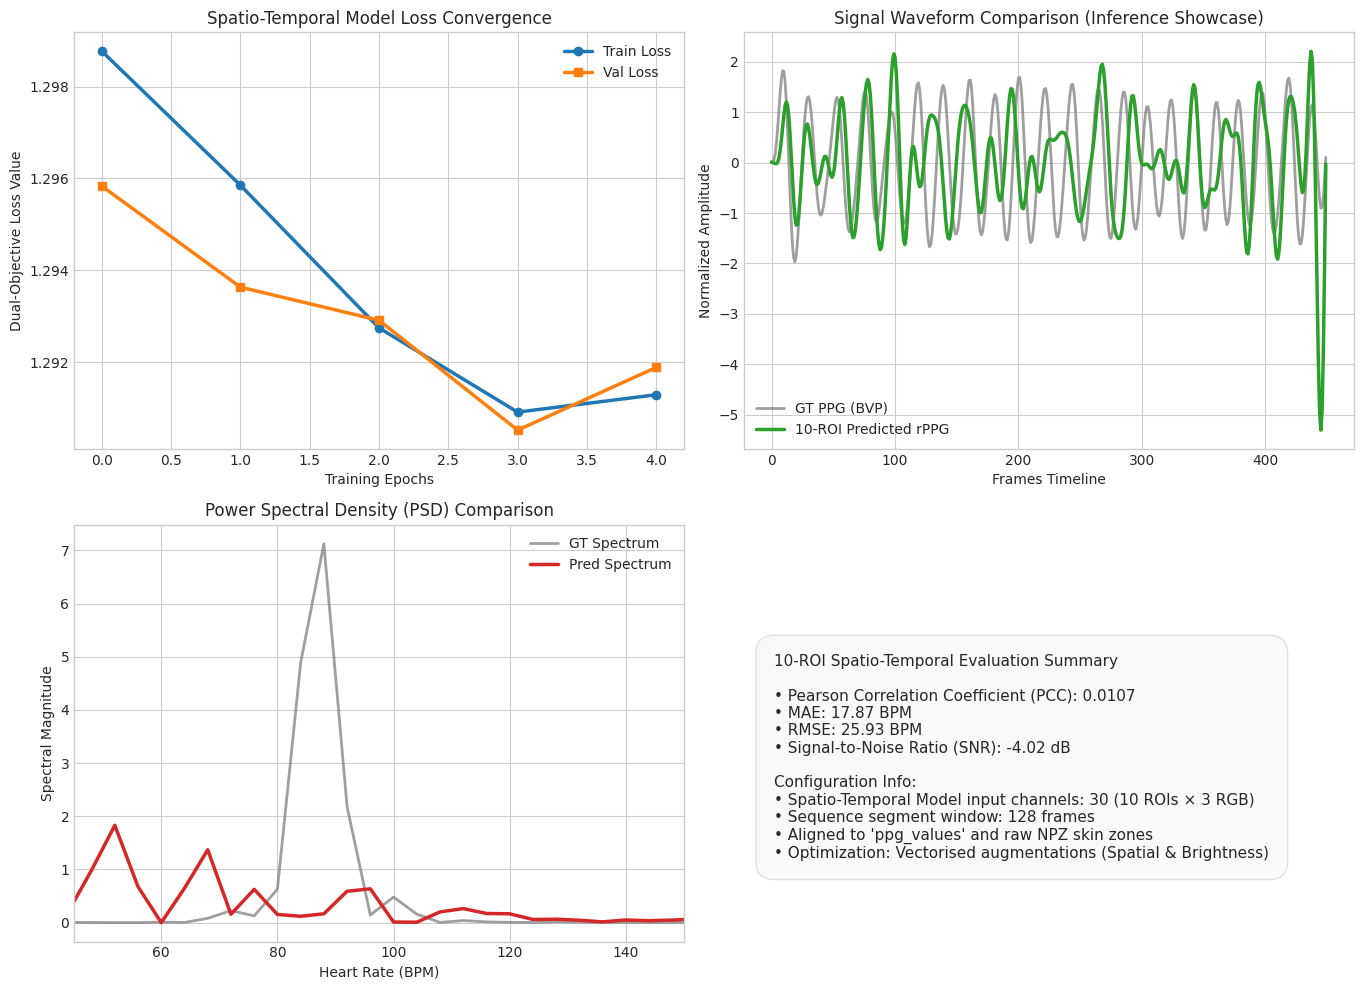

In [6]:
def run_inference_on_sample(npz_file_path, trained_model, sequence_length=450, fs=30.0):
    """Execute inference on a single NPZ validation sample sequence."""
    print(f"--- INFERENCE RUN ON: {os.path.basename(npz_file_path)} ---")
    data = load_npz_file(npz_file_path)
    if data is None:
        return None
    
    ppg_key = 'ppg_values' if 'ppg_values' in data else 'ppg'
    if len(data[ppg_key]) < sequence_length:
        print("Error: Input file length is shorter than the sequence length.")
        return None
        
    target_ppg = data[ppg_key][:sequence_length]
    target_ppg = butter_bandpass_filter(target_ppg, fs=fs)
    target_norm = (target_ppg - np.mean(target_ppg)) / (np.std(target_ppg) + 1e-8)
    
    roi_inputs = []
    for roi_name in ROI_ORDER:
        actual_key = next((k for k in data.files if roi_name == k), None)
        if actual_key is not None:
            roi_data = data[actual_key][:sequence_length]
        else:
            roi_data = np.zeros((sequence_length, 24, 24, 3), dtype=np.uint8)
        roi_inputs.append(roi_data.astype(np.float32) / 255.0)
        
    stacked_rois = np.stack(roi_inputs, axis=0)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))
    stacked_rois = np.reshape(stacked_rois, (30, sequence_length, 24, 24))
    
    input_tensor = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    trained_model.eval()
    with torch.no_grad():
        output_signal = trained_model(input_tensor).cpu().numpy()[0]
        
    filtered_pred = butter_bandpass_filter(output_signal, fs=fs)
    filtered_pred = (filtered_pred - np.mean(filtered_pred)) / (np.std(filtered_pred) + 1e-8)
    
    hr_pred = calculate_bpm_from_fft(filtered_pred, fs=fs)
    hr_true = calculate_bpm_from_fft(target_norm, fs=fs)
    
    print(f"  Predicted HR : {hr_pred:.2f} BPM")
    print(f"  Ground-Truth : {hr_true:.2f} BPM")
    print(f"  Absolute Error: {abs(hr_pred - hr_true):.2f} BPM")
    print("----------------------------------------------------\n")
    return filtered_pred, target_norm

sample_val_file = val_split[0]
inference_pred, inference_gt = run_inference_on_sample(sample_val_file, model)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o')
axs[0, 0].plot(val_losses, label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s')
axs[0, 0].set_title('Spatio-Temporal Model Loss Convergence')
axs[0, 0].set_xlabel('Training Epochs')
axs[0, 0].set_ylabel('Dual-Objective Loss Value')
axs[0, 0].legend()

if inference_pred is not None:
    axs[0, 1].plot(inference_gt, label='GT PPG (BVP)', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[0, 1].plot(inference_pred, label='10-ROI Predicted rPPG', color='#2ca02c', linewidth=2.5)
    axs[0, 1].set_title('Signal Waveform Comparison (Inference Showcase)')
    axs[0, 1].set_xlabel('Frames Timeline')
    axs[0, 1].set_ylabel('Normalized Amplitude')
    axs[0, 1].legend()

if inference_pred is not None:
    pred_det = inference_pred - np.mean(inference_pred)
    true_det = inference_gt - np.mean(inference_gt)
    
    freqs_p, psd_p = welch(pred_det, fs=30.0, nperseg=len(pred_det))
    freqs_t, psd_t = welch(true_det, fs=30.0, nperseg=len(true_det))
    
    axs[1, 0].plot(freqs_t * 60.0, psd_t, label='GT Spectrum', color='#7f7f7f', alpha=0.75, linewidth=2)
    axs[1, 0].plot(freqs_p * 60.0, psd_p, label='Pred Spectrum', color='#d62728', linewidth=2.5)
    axs[1, 0].set_xlim(45, 150)
    axs[1, 0].set_title('Power Spectral Density (PSD) Comparison')
    axs[1, 0].set_xlabel('Heart Rate (BPM)')
    axs[1, 0].set_ylabel('Spectral Magnitude')
    axs[1, 0].legend()

axs[1, 1].axis('off')
metric_summary_card = (
    "10-ROI Spatio-Temporal Evaluation Summary\n\n"
    f"• Pearson Correlation Coefficient (PCC): {metrics['PCC']:.4f}\n"
    f"• MAE: {metrics['MAE']:.2f} BPM\n"
    f"• RMSE: {metrics['RMSE']:.2f} BPM\n"
    f"• Signal-to-Noise Ratio (SNR): {metrics['SNR']:.2f} dB\n\n"
    f"Configuration Info:\n"
    f"• Spatio-Temporal Model input channels: 30 (10 ROIs × 3 RGB)\n"
    f"• Sequence segment window: 128 frames\n"
    f"• Aligned to 'ppg_values' and raw NPZ skin zones\n"
    f"• Optimization: Vectorised augmentations (Spatial & Brightness)"
)
axs[1, 1].text(0.05, 0.2, metric_summary_card, fontsize=11, 
              bbox=dict(boxstyle='round,pad=1.2', facecolor='#f8f9fa', edgecolor='#dee2e6'))

plt.tight_layout()
plt.show()

W0000 00:00:1784805360.184975 4193674 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1784805360.200529 4193674 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1784805360.206481 4193733 gl_context.cc:343] failed to get GL_VERSION string
I0000 00:00:1784805360.206501 4193733 gl_context.cc:385] GL version: 3.2 (), renderer: (null)
E0000 00:00:1784805360.206516 4193733 gl_context.cc:310] Error querying for GL extensions
I0000 00:00:1784805360.206902 4193674 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1784805360.211640 4193734 gl_context.cc:343] failed to get GL_VERSION string
I0000 00:00:1784805360.211667 4193734 gl_context.cc:385] GL version: 3.2 (), renderer: (null)
E0000 00:00:1784805360.211691 4193734 gl_context.cc:310] Error querying for GL extensions
I0000 00:00:1784805360.212018 4193674 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor:

Successfully loaded model weights from: spatiotemporal_physnet_best.pth
Loaded 450 frames from '9998_USBVideo_after.avi' @ 30.00 FPS

Model Input Tensor Shape : torch.Size([1, 30, 450, 24, 24])
Target Hardware Execution : cuda:1


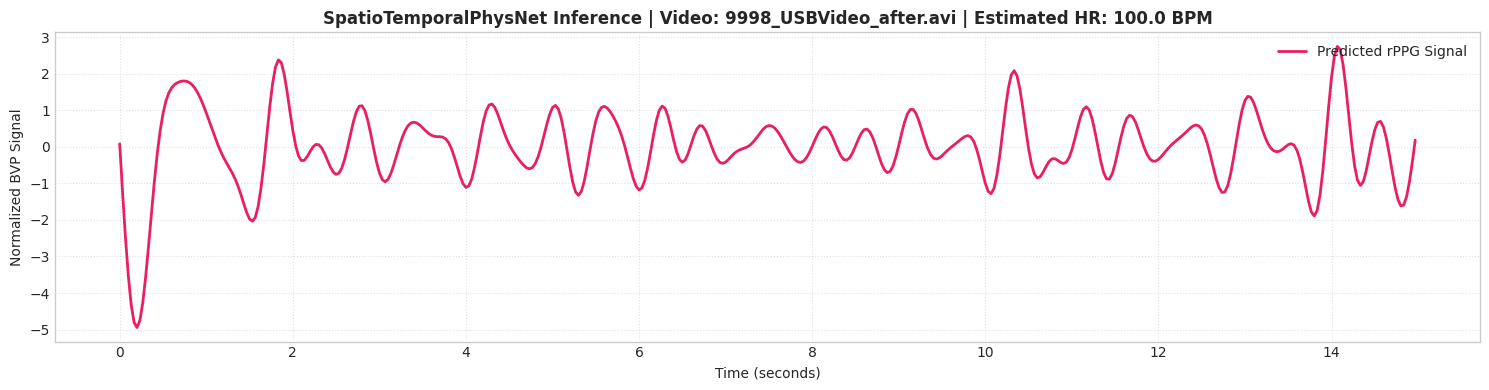

In [10]:
# ============================================================================
# Standalone Inference Cell: Video (.avi) -> MediaPipe 10-ROI -> PhysNet Model
# ============================================================================
import os
import cv2
import math
import imageio
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ----------------------------------------------------------------------------
# 1. Configuration & Constants
# ----------------------------------------------------------------------------
VIDEO_PATH = '/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/video/9998_USBVideo_after.avi'  # Path to your target .avi video
MEDIAPIPE_MODEL_PATH = '/home/cristic/face_landmarker.task'
MODEL_CHECKPOINT_PATH = 'spatiotemporal_physnet_best.pth'

CHUNK_SIZE = 450
ROI_BOX_SIZE = (24, 24)
DEVICE = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

# Exact 10 ROI ordering expected by SpatioTemporalPhysNet (30 input channels)
ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'
]

# MediaPipe landmark mappings for the 10 ROIs
ROIS_MAPPING = {
    'roi_full_face': list(range(468)),
    'roi_forehead': [10, 67, 69, 108, 109, 151, 337, 338, 297, 299, 9, 8],
    'roi_left_eye': [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246],
    'roi_right_eye': [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398],
    'roi_nose': [1, 2, 98, 327, 328, 2, 4, 5, 195, 197, 6, 168],
    'roi_mouth': [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 308, 324, 318, 402, 317, 14, 87, 178, 95],
    'roi_chin': [152, 148, 176, 149, 150, 136, 172, 377, 400, 378, 379, 365, 397],
    'roi_right_cheek_50': [50],
    'roi_left_cheek_280': [280],
    'roi_chin_199': [199]
}

# ----------------------------------------------------------------------------
# 2. MediaPipe Detector & ROI Helper Definitions
# ----------------------------------------------------------------------------
class ModernFaceMeshDetector:
    def __init__(self, model_path):
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.FaceLandmarkerOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.VIDEO,
            num_faces=1,
            min_face_detection_confidence=0.5,
            min_face_presence_confidence=0.5,
            min_tracking_confidence=0.5
        )
        self.landmarker = vision.FaceLandmarker.create_from_options(options)
        self.timestamp_ms = 0

    def detect_landmarks(self, frame_rgb):
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        self.timestamp_ms += 33  # ~30 FPS step
        detection_result = self.landmarker.detect_for_video(mp_image, self.timestamp_ms)
        
        if detection_result.face_landmarks:
            h, w = frame_rgb.shape[:2]
            landmarks = detection_result.face_landmarks[0]
            # Convert normalized coordinates to pixel coordinates
            return np.array([[lm.x * w, lm.y * h] for lm in landmarks], dtype=np.float32)
        return None

    def reset(self):
        self.timestamp_ms = 0

    def close(self):
        self.landmarker.close()


def extract_roi_bbox(landmarks, indices, frame_shape, target_size=(24, 24)):
    h, w = frame_shape
    roi_lms = landmarks[indices]
    
    if len(indices) == 1:
        # Point landmark (e.g., cheek, chin point) -> center crop around landmark
        cx, cy = roi_lms[0]
        crop_w, crop_h = target_size
        x = int(cx - crop_w / 2)
        y = int(cy - crop_h / 2)
    else:
        # Multi-point ROI -> calculate bounding box
        min_x, min_y = np.min(roi_lms, axis=0)
        max_x, max_y = np.max(roi_lms, axis=0)
        x, y = int(min_x), int(min_y)
        crop_w, crop_h = int(max_x - min_x), int(max_y - min_y)
        
    x = max(0, min(x, w - 1))
    y = max(0, min(y, h - 1))
    crop_w = max(1, min(crop_w, w - x))
    crop_h = max(1, min(crop_h, h - y))
    
    return (x, y, crop_w, crop_h)


def extract_roi_region(frame, bbox, target_size=ROI_BOX_SIZE):
    x, y, w, h = bbox
    crop = frame[y:y+h, x:x+w]
    if crop.size == 0:
        return np.zeros((*target_size, 3), dtype=np.uint8)
    return cv2.resize(crop, target_size, interpolation=cv2.INTER_AREA)

# ----------------------------------------------------------------------------
# 3. Signal Processing Helper Functions
# ----------------------------------------------------------------------------
def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

# ----------------------------------------------------------------------------
# 4. Model Architecture Load
# ----------------------------------------------------------------------------
class SpatioTemporalPhysNet(nn.Module):
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels
        
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))
        )
        
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        x_spatial = self.spatial_conv(x)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        ppg_pred = self.temporal_encoder(x_spatial)
        return torch.squeeze(ppg_pred, dim=1)

# ----------------------------------------------------------------------------
# 5. Video Processing Pipeline
# ----------------------------------------------------------------------------
def process_video_for_physnet(video_path, detector, chunk_size=CHUNK_SIZE):
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found at: {video_path}")
        
    reader = imageio.get_reader(video_path, 'ffmpeg')
    meta = reader.get_meta_data()
    fps = meta.get('fps', 30.0)
    
    frames = []
    for i, frame in enumerate(reader):
        if i >= chunk_size:
            break
        frames.append(frame)
    reader.close()
    
    num_frames = len(frames)
    print(f"Loaded {num_frames} frames from '{os.path.basename(video_path)}' @ {fps:.2f} FPS")
    
    # Pad short videos if needed
    if num_frames < chunk_size:
        pad_count = chunk_size - num_frames
        frames += [frames[-1]] * pad_count
        print(f"Padded video from {num_frames} to {chunk_size} frames.")
        
    # Extract landmarks per frame
    chunk_landmarks = []
    detector.reset()
    for frame in frames:
        lms = detector.detect_landmarks(frame)
        if lms is not None:
            chunk_landmarks.append(lms)
        elif chunk_landmarks:
            chunk_landmarks.append(chunk_landmarks[-1].copy())
        else:
            chunk_landmarks.append(np.zeros((468, 2), dtype='float32'))
            
    chunk_landmarks = np.array(chunk_landmarks)
    
    # Crop ROIs for all frames
    roi_inputs = []
    for roi_name in ROI_ORDER:
        roi_indices = ROIS_MAPPING[roi_name]
        roi_frames = []
        for frame_idx, frame in enumerate(frames):
            landmarks = chunk_landmarks[frame_idx]
            if np.all(landmarks == 0):
                h, w = frame.shape[:2]
                bbox = (w // 2 - ROI_BOX_SIZE[0] // 2, h // 2 - ROI_BOX_SIZE[1] // 2, ROI_BOX_SIZE[0], ROI_BOX_SIZE[1])
            else:
                bbox = extract_roi_bbox(landmarks, roi_indices, frame.shape[:2], ROI_BOX_SIZE)
            
            roi_region = extract_roi_region(frame, bbox)
            roi_frames.append(roi_region)
            
        roi_array = np.array(roi_frames, dtype=np.float32) / 255.0  # (T, 24, 24, 3)
        roi_inputs.append(roi_array)
        
    # Format shape to match model input: (10, T, H, W, C) -> (1, 30, T, 24, 24)
    stacked_rois = np.stack(roi_inputs, axis=0)                     # (10, 450, 24, 24, 3)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))     # (10, 3, 450, 24, 24)
    stacked_rois = np.reshape(stacked_rois, (10 * 3, CHUNK_SIZE, 24, 24)) # (30, 450, 24, 24)
    
    tensor_input = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0) # (1, 30, 450, 24, 24)
    return tensor_input, fps

# ----------------------------------------------------------------------------
# 6. Pipeline Execution
# ----------------------------------------------------------------------------
# Initialize MediaPipe Detector
detector = ModernFaceMeshDetector(model_path=MEDIAPIPE_MODEL_PATH)

# Initialize Model & Load Weights
model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
if os.path.exists(MODEL_CHECKPOINT_PATH):
    # checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location=DEVICE)
    checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    print(f"Successfully loaded model weights from: {MODEL_CHECKPOINT_PATH}")
else:
    print(f"[Warning] Checkpoint '{MODEL_CHECKPOINT_PATH}' not found. Using randomly initialized model.")

model.eval()

# Process video and perform forward pass
input_tensor, video_fps = process_video_for_physnet(VIDEO_PATH, detector, chunk_size=CHUNK_SIZE)
input_tensor = input_tensor.to(DEVICE)

print(f"\nModel Input Tensor Shape : {input_tensor.shape}")
print(f"Target Hardware Execution : {DEVICE}")

with torch.no_grad():
    predicted_ppg = model(input_tensor).squeeze(0).cpu().numpy()

# Post-processing & HR Extraction
filtered_ppg = butter_bandpass_filter(predicted_ppg, fs=video_fps)
normalized_ppg = (filtered_ppg - np.mean(filtered_ppg)) / (np.std(filtered_ppg) + 1e-8)
estimated_bpm = calculate_bpm_from_fft(filtered_ppg, fs=video_fps)

# Render Waveform Visualization
timeline = np.arange(len(normalized_ppg)) / video_fps
plt.figure(figsize=(15, 4))
plt.plot(timeline, normalized_ppg, color='#e91e63', linewidth=2, label='Predicted rPPG Signal')
plt.title(f"SpatioTemporalPhysNet Inference | Video: {os.path.basename(VIDEO_PATH)} | Estimated HR: {estimated_bpm:.1f} BPM", fontsize=12, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized BVP Signal")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Clean up detector
detector.close()

In [11]:
import pandas as pd

CSV_PATH = "/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/db.csv"

# Load header only for instant inspection
df = pd.read_csv(CSV_PATH, nrows=5)

print(f"Total Columns ({len(df.columns)}):")
print(df.columns.tolist())

Total Columns (25):
['patient_id', 'weight', 'height', 'bmi', 'age', 'sex', 'upper_ap', 'lower_ap', 'saturation', 'temperature', 'hemoglobin', 'glycated_hemoglobin', 'cholesterol', 'respiratory', 'rigidity', 'pulse', 'stress', 'step', 'camera', 'view', 'ecg', 'ppg', 'video', 'meta', 'ppg_sync']


In [12]:
import pandas as pd

CSV_PATH = "/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/db.csv"
df = pd.read_csv(CSV_PATH)

# Support flexible column naming depending on exact header case/alias
patient_col = 'patient_id' if 'patient_id' in df.columns else 'patient'

# Filter by subject 9998 and USBVideo camera
filtered_df = df[
    (df[patient_col].astype(str).str.contains('9998')) & 
    (df['camera'].astype(str).str.contains('USBVideo', case=False, na=False))
]

# Display relevant identification columns alongside pulse
display_cols = [col for col in [patient_col, 'step', 'camera', 'view', 'pulse'] if col in df.columns]
print(filtered_df[display_cols])

      patient_id    step    camera  view  pulse
3595        9998   after  USBVideo  left  117.0
3598        9998  before  USBVideo  left  100.0


Loaded 450 frames from '1091_USBVideo_before.avi' @ 30.00 FPS

Model Input Tensor Shape : torch.Size([1, 30, 450, 24, 24])
Target Hardware Execution : cuda:1


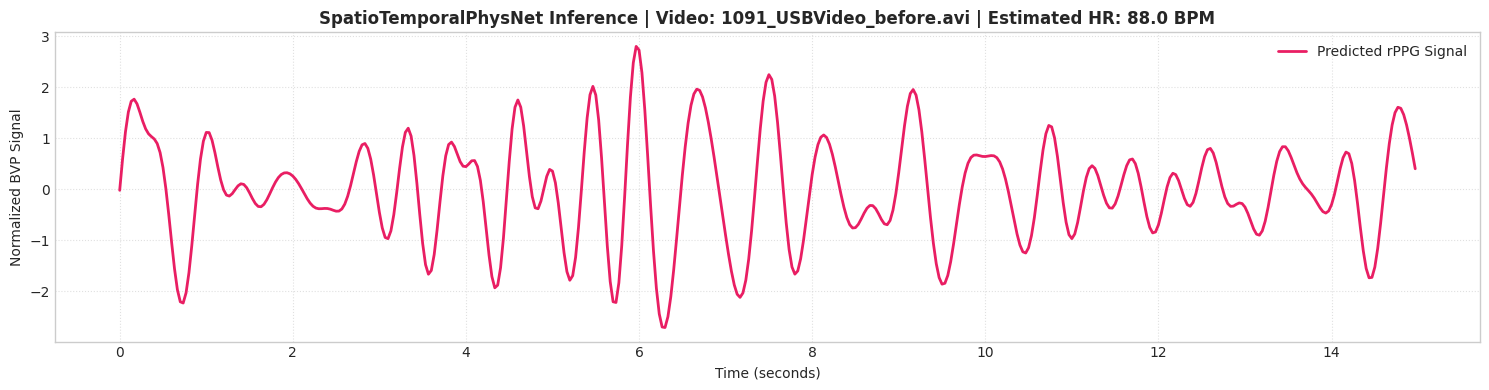

In [13]:
# Process video and perform forward pass
VIDEO_PATH = '/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/video/1091_USBVideo_before.avi' 
input_tensor, video_fps = process_video_for_physnet(VIDEO_PATH, detector, chunk_size=CHUNK_SIZE)
input_tensor = input_tensor.to(DEVICE)

print(f"\nModel Input Tensor Shape : {input_tensor.shape}")
print(f"Target Hardware Execution : {DEVICE}")

with torch.no_grad():
    predicted_ppg = model(input_tensor).squeeze(0).cpu().numpy()

# Post-processing & HR Extraction
filtered_ppg = butter_bandpass_filter(predicted_ppg, fs=video_fps)
normalized_ppg = (filtered_ppg - np.mean(filtered_ppg)) / (np.std(filtered_ppg) + 1e-8)
estimated_bpm = calculate_bpm_from_fft(filtered_ppg, fs=video_fps)

# Render Waveform Visualization
timeline = np.arange(len(normalized_ppg)) / video_fps
plt.figure(figsize=(15, 4))
plt.plot(timeline, normalized_ppg, color='#e91e63', linewidth=2, label='Predicted rPPG Signal')
plt.title(f"SpatioTemporalPhysNet Inference | Video: {os.path.basename(VIDEO_PATH)} | Estimated HR: {estimated_bpm:.1f} BPM", fontsize=12, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized BVP Signal")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Clean up detector
detector.close()

In [14]:
# Filter by subject 9998 and USBVideo camera
filtered_df = df[
    (df[patient_col].astype(str).str.contains('1091')) & 
    (df['camera'].astype(str).str.contains('USBVideo', case=False, na=False))
]

# Display relevant identification columns alongside pulse
display_cols = [col for col in [patient_col, 'step', 'camera', 'view', 'pulse'] if col in df.columns]
print(filtered_df[display_cols])

    patient_id    step    camera  view  pulse
19        1091   after  USBVideo  left  132.0
22        1091  before  USBVideo  left   94.0


W0000 00:00:1784806058.704072   25014 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1784806058.718635   25014 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1784806058.725566   25073 gl_context.cc:343] failed to get GL_VERSION string
I0000 00:00:1784806058.725594   25073 gl_context.cc:385] GL version: 3.2 (), renderer: (null)
E0000 00:00:1784806058.725612   25073 gl_context.cc:310] Error querying for GL extensions
I0000 00:00:1784806058.725978   25014 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1784806058.733225   25074 gl_context.cc:343] failed to get GL_VERSION string
I0000 00:00:1784806058.733247   25074 gl_context.cc:385] GL version: 3.2 (), renderer: (null)
E0000 00:00:1784806058.733259   25074 gl_context.cc:310] Error querying for GL extensions
I0000 00:00:1784806058.733757   25014 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor:

Successfully loaded model weights from: spatiotemporal_long_window450_physnet_best2.pth
Loaded 450 frames from '9998_USBVideo_after.avi' @ 30.00 FPS

Model Input Tensor Shape : torch.Size([1, 30, 450, 24, 24])
Target Hardware Execution : cuda:1


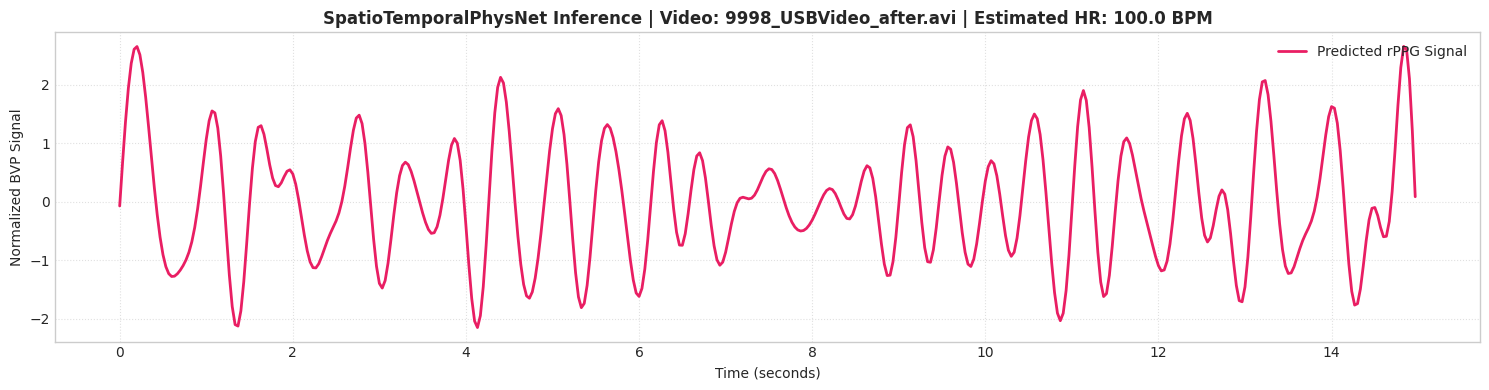

In [15]:
# ============================================================================
# Standalone Inference Cell: Video (.avi) -> MediaPipe 10-ROI -> PhysNet Model
# ============================================================================
import os
import cv2
import math
import imageio
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ----------------------------------------------------------------------------
# 1. Configuration & Constants
# ----------------------------------------------------------------------------
VIDEO_PATH = '/home/cristic/data/Bgeorge/mcd_rppg/snapshots/929fb19c5ff2b5c8ed64a7c3a123744346674e88/video/9998_USBVideo_after.avi'  # Path to your target .avi video
MEDIAPIPE_MODEL_PATH = '/home/cristic/face_landmarker.task'
MODEL_CHECKPOINT_PATH = 'spatiotemporal_long_window450_physnet_best2.pth'

CHUNK_SIZE = 450
ROI_BOX_SIZE = (24, 24)
DEVICE = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

# Exact 10 ROI ordering expected by SpatioTemporalPhysNet (30 input channels)
ROI_ORDER = [
    'roi_forehead',
    'roi_left_cheek_280',
    'roi_right_cheek_50',
    'roi_nose',
    'roi_chin',
    'roi_chin_199',
    'roi_left_eye',
    'roi_right_eye',
    'roi_mouth',
    'roi_full_face'
]

# MediaPipe landmark mappings for the 10 ROIs
ROIS_MAPPING = {
    'roi_full_face': list(range(468)),
    'roi_forehead': [10, 67, 69, 108, 109, 151, 337, 338, 297, 299, 9, 8],
    'roi_left_eye': [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246],
    'roi_right_eye': [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398],
    'roi_nose': [1, 2, 98, 327, 328, 2, 4, 5, 195, 197, 6, 168],
    'roi_mouth': [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 308, 324, 318, 402, 317, 14, 87, 178, 95],
    'roi_chin': [152, 148, 176, 149, 150, 136, 172, 377, 400, 378, 379, 365, 397],
    'roi_right_cheek_50': [50],
    'roi_left_cheek_280': [280],
    'roi_chin_199': [199]
}

# ----------------------------------------------------------------------------
# 2. MediaPipe Detector & ROI Helper Definitions
# ----------------------------------------------------------------------------
class ModernFaceMeshDetector:
    def __init__(self, model_path):
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = vision.FaceLandmarkerOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.VIDEO,
            num_faces=1,
            min_face_detection_confidence=0.5,
            min_face_presence_confidence=0.5,
            min_tracking_confidence=0.5
        )
        self.landmarker = vision.FaceLandmarker.create_from_options(options)
        self.timestamp_ms = 0

    def detect_landmarks(self, frame_rgb):
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        self.timestamp_ms += 33  # ~30 FPS step
        detection_result = self.landmarker.detect_for_video(mp_image, self.timestamp_ms)
        
        if detection_result.face_landmarks:
            h, w = frame_rgb.shape[:2]
            landmarks = detection_result.face_landmarks[0]
            # Convert normalized coordinates to pixel coordinates
            return np.array([[lm.x * w, lm.y * h] for lm in landmarks], dtype=np.float32)
        return None

    def reset(self):
        self.timestamp_ms = 0

    def close(self):
        self.landmarker.close()


def extract_roi_bbox(landmarks, indices, frame_shape, target_size=(24, 24)):
    h, w = frame_shape
    roi_lms = landmarks[indices]
    
    if len(indices) == 1:
        # Point landmark (e.g., cheek, chin point) -> center crop around landmark
        cx, cy = roi_lms[0]
        crop_w, crop_h = target_size
        x = int(cx - crop_w / 2)
        y = int(cy - crop_h / 2)
    else:
        # Multi-point ROI -> calculate bounding box
        min_x, min_y = np.min(roi_lms, axis=0)
        max_x, max_y = np.max(roi_lms, axis=0)
        x, y = int(min_x), int(min_y)
        crop_w, crop_h = int(max_x - min_x), int(max_y - min_y)
        
    x = max(0, min(x, w - 1))
    y = max(0, min(y, h - 1))
    crop_w = max(1, min(crop_w, w - x))
    crop_h = max(1, min(crop_h, h - y))
    
    return (x, y, crop_w, crop_h)


def extract_roi_region(frame, bbox, target_size=ROI_BOX_SIZE):
    x, y, w, h = bbox
    crop = frame[y:y+h, x:x+w]
    if crop.size == 0:
        return np.zeros((*target_size, 3), dtype=np.uint8)
    return cv2.resize(crop, target_size, interpolation=cv2.INTER_AREA)

# ----------------------------------------------------------------------------
# 3. Signal Processing Helper Functions
# ----------------------------------------------------------------------------
def butter_bandpass_filter(data, lowcut=0.75, highcut=2.5, fs=30.0, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def calculate_bpm_from_fft(signal_1d, fs=30.0, lowcut=0.75, highcut=2.5):
    signal_cleaned = signal_1d - np.mean(signal_1d)
    freqs, psd = welch(signal_cleaned, fs=fs, nperseg=len(signal_cleaned))
    valid_idx = np.where((freqs >= lowcut) & (freqs <= highcut))[0]
    if len(valid_idx) == 0:
        return 75.0
    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    return peak_freq * 60.0

# ----------------------------------------------------------------------------
# 4. Model Architecture Load
# ----------------------------------------------------------------------------
class SpatioTemporalPhysNet(nn.Module):
    def __init__(self, num_rois=10, in_channels=3):
        super(SpatioTemporalPhysNet, self).__init__()
        self.num_rois = num_rois
        self.total_channels = num_rois * in_channels
        
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(self.total_channels, 64, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.BatchNorm3d(64),
            nn.ELU(),
            nn.AdaptiveAvgPool3d((None, 1, 1))
        )
        
        self.temporal_encoder = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ELU(),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.BatchNorm1d(16),
            nn.ELU(),
            nn.Conv1d(16, 1, kernel_size=1)
        )

    def forward(self, x):
        x_spatial = self.spatial_conv(x)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        x_spatial = torch.squeeze(x_spatial, dim=-1)
        ppg_pred = self.temporal_encoder(x_spatial)
        return torch.squeeze(ppg_pred, dim=1)

# ----------------------------------------------------------------------------
# 5. Video Processing Pipeline
# ----------------------------------------------------------------------------
def process_video_for_physnet(video_path, detector, chunk_size=CHUNK_SIZE):
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found at: {video_path}")
        
    reader = imageio.get_reader(video_path, 'ffmpeg')
    meta = reader.get_meta_data()
    fps = meta.get('fps', 30.0)
    
    frames = []
    for i, frame in enumerate(reader):
        if i >= chunk_size:
            break
        frames.append(frame)
    reader.close()
    
    num_frames = len(frames)
    print(f"Loaded {num_frames} frames from '{os.path.basename(video_path)}' @ {fps:.2f} FPS")
    
    # Pad short videos if needed
    if num_frames < chunk_size:
        pad_count = chunk_size - num_frames
        frames += [frames[-1]] * pad_count
        print(f"Padded video from {num_frames} to {chunk_size} frames.")
        
    # Extract landmarks per frame
    chunk_landmarks = []
    detector.reset()
    for frame in frames:
        lms = detector.detect_landmarks(frame)
        if lms is not None:
            chunk_landmarks.append(lms)
        elif chunk_landmarks:
            chunk_landmarks.append(chunk_landmarks[-1].copy())
        else:
            chunk_landmarks.append(np.zeros((468, 2), dtype='float32'))
            
    chunk_landmarks = np.array(chunk_landmarks)
    
    # Crop ROIs for all frames
    roi_inputs = []
    for roi_name in ROI_ORDER:
        roi_indices = ROIS_MAPPING[roi_name]
        roi_frames = []
        for frame_idx, frame in enumerate(frames):
            landmarks = chunk_landmarks[frame_idx]
            if np.all(landmarks == 0):
                h, w = frame.shape[:2]
                bbox = (w // 2 - ROI_BOX_SIZE[0] // 2, h // 2 - ROI_BOX_SIZE[1] // 2, ROI_BOX_SIZE[0], ROI_BOX_SIZE[1])
            else:
                bbox = extract_roi_bbox(landmarks, roi_indices, frame.shape[:2], ROI_BOX_SIZE)
            
            roi_region = extract_roi_region(frame, bbox)
            roi_frames.append(roi_region)
            
        roi_array = np.array(roi_frames, dtype=np.float32) / 255.0  # (T, 24, 24, 3)
        roi_inputs.append(roi_array)
        
    # Format shape to match model input: (10, T, H, W, C) -> (1, 30, T, 24, 24)
    stacked_rois = np.stack(roi_inputs, axis=0)                     # (10, 450, 24, 24, 3)
    stacked_rois = np.transpose(stacked_rois, (0, 4, 1, 2, 3))     # (10, 3, 450, 24, 24)
    stacked_rois = np.reshape(stacked_rois, (10 * 3, CHUNK_SIZE, 24, 24)) # (30, 450, 24, 24)
    
    tensor_input = torch.tensor(stacked_rois, dtype=torch.float32).unsqueeze(0) # (1, 30, 450, 24, 24)
    return tensor_input, fps

# ----------------------------------------------------------------------------
# 6. Pipeline Execution
# ----------------------------------------------------------------------------
# Initialize MediaPipe Detector
detector = ModernFaceMeshDetector(model_path=MEDIAPIPE_MODEL_PATH)

# Initialize Model & Load Weights
model = SpatioTemporalPhysNet(num_rois=10).to(DEVICE)
if os.path.exists(MODEL_CHECKPOINT_PATH):
    # checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location=DEVICE)
    checkpoint = torch.load(MODEL_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    print(f"Successfully loaded model weights from: {MODEL_CHECKPOINT_PATH}")
else:
    print(f"[Warning] Checkpoint '{MODEL_CHECKPOINT_PATH}' not found. Using randomly initialized model.")

model.eval()

# Process video and perform forward pass
input_tensor, video_fps = process_video_for_physnet(VIDEO_PATH, detector, chunk_size=CHUNK_SIZE)
input_tensor = input_tensor.to(DEVICE)

print(f"\nModel Input Tensor Shape : {input_tensor.shape}")
print(f"Target Hardware Execution : {DEVICE}")

with torch.no_grad():
    predicted_ppg = model(input_tensor).squeeze(0).cpu().numpy()

# Post-processing & HR Extraction
filtered_ppg = butter_bandpass_filter(predicted_ppg, fs=video_fps)
normalized_ppg = (filtered_ppg - np.mean(filtered_ppg)) / (np.std(filtered_ppg) + 1e-8)
estimated_bpm = calculate_bpm_from_fft(filtered_ppg, fs=video_fps)

# Render Waveform Visualization
timeline = np.arange(len(normalized_ppg)) / video_fps
plt.figure(figsize=(15, 4))
plt.plot(timeline, normalized_ppg, color='#e91e63', linewidth=2, label='Predicted rPPG Signal')
plt.title(f"SpatioTemporalPhysNet Inference | Video: {os.path.basename(VIDEO_PATH)} | Estimated HR: {estimated_bpm:.1f} BPM", fontsize=12, fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized BVP Signal")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Clean up detector
detector.close()